# LiH: Random Forest Training

Trains an RF model on 6-qubit LiH data (61 non-trivial observables).
Matches H₂ training_RF.ipynb structure.

In [1]:
import numpy as np
import json
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from qiskit.quantum_info import Pauli
from qiskit_ibm_runtime.fake_provider import FakeJakartaV2
import joblib

print('All imports OK')

All imports OK


## 1. Load Dataset

In [2]:
ideal_data = np.load('lih_ideal_data.npy')
noisy_data = np.load('lih_noisy_data.npy')
theta_samples = np.load('lih_theta_samples.npy')

with open('lih_meta.json') as f:
    meta = json.load(f)

PAULI_LABELS = meta['pauli_labels']
PAULI_COEFFS = meta['hamiltonian_coeffs']
N_QUBITS = meta['n_qubits']

print(f'Dataset: {ideal_data.shape[0]} samples, {ideal_data.shape[1]} Pauli terms')
print(f'Qubits: {N_QUBITS}')
print(f'\nTrain: 1800 θ values')
print(f'Test:  200 θ values (held out)')

Dataset: 2000 samples, 62 Pauli terms
Qubits: 6

Train: 1800 θ values
Test:  200 θ values (held out)


## 2. Per-Qubit Noise Parameters

In [3]:
backend = FakeJakartaV2()
props = backend.properties()

qubit_props = {}
for q in range(N_QUBITS):
    t1 = props.qubit_property(q, 'T1')[0] * 1e6
    t2 = props.qubit_property(q, 'T2')[0] * 1e6
    err = props.qubit_property(q, 'readout_error')[0]
    qubit_props[q] = {'T1': t1, 'T2': t2, 'readout_error': err}
    print(f'Qubit {q}: T1={t1:.2f}µs  T2={t2:.2f}µs  readout_err={err:.4f}')

Qubit 0: T1=81.76µs  T2=41.46µs  readout_err=0.0210
Qubit 1: T1=134.60µs  T2=27.52µs  readout_err=0.0205
Qubit 2: T1=137.79µs  T2=20.28µs  readout_err=0.0160
Qubit 3: T1=112.68µs  T2=34.23µs  readout_err=0.0253
Qubit 4: T1=117.51µs  T2=74.64µs  readout_err=0.0490
Qubit 5: T1=146.18µs  T2=56.93µs  readout_err=0.0555


## 3. Build Feature Vectors (33 features)

In [4]:
SYMPLECTIC = {label: np.concatenate([Pauli(label).x.astype(int), Pauli(label).z.astype(int)])
              for label in PAULI_LABELS}

N_2Q = meta['n_2q_gates']
N_SX = meta['n_sx_gates']
ALL_OBS = list(range(1, len(PAULI_LABELS)))  # skip identity

def qubit_noise_features(symp):
    feats = []
    for q in range(N_QUBITS):
        active = float(symp[q] == 1 or symp[q + N_QUBITS] == 1)
        feats.extend([
            qubit_props[q]['T1'] * active,
            qubit_props[q]['T2'] * active,
            qubit_props[q]['readout_error'] * active,
        ])
    return feats

def build_features(noisy_subset, ideal_subset, obs_indices):
    rows_X, rows_y = [], []
    for obs_idx in obs_indices:
        label = PAULI_LABELS[obs_idx]
        symp = SYMPLECTIC[label]
        noise_feats = qubit_noise_features(symp)
        for i in range(len(noisy_subset)):
            rows_X.append([noisy_subset[i, obs_idx], *symp, N_2Q, N_SX, *noise_feats])
            rows_y.append(ideal_subset[i, obs_idx])
    return np.array(rows_X, dtype=np.float32), np.array(rows_y, dtype=np.float32)

N_TRAIN = 1800
ideal_test = ideal_data[N_TRAIN:]
noisy_test = noisy_data[N_TRAIN:]

X_train, y_train = build_features(noisy_data[:N_TRAIN], ideal_data[:N_TRAIN], ALL_OBS)
X_test, y_test = build_features(noisy_test, ideal_test, ALL_OBS)
baseline_mae = mean_absolute_error(y_test, X_test[:, 0])

print(f'Training set: {X_train.shape}')
print(f'Test set:     {X_test.shape}')
print(f'Features per sample: {X_train.shape[1]}')
print(f'Baseline (unmitigated) MAE: {baseline_mae:.4f}')

Training set: (109800, 33)
Test set:     (12200, 33)
Features per sample: 33
Baseline (unmitigated) MAE: 0.0406


## 4. Train Random Forest

In [5]:
rf = RandomForestRegressor(
    n_estimators=100, max_depth=None, min_samples_leaf=1,
    random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)

train_pred = rf.predict(X_train)
test_pred = rf.predict(X_test)

train_mae = mean_absolute_error(y_train, train_pred)
test_mae = mean_absolute_error(y_test, test_pred)

print(f'Training MAE:    {train_mae:.4f}')
print(f'Test MAE:        {test_mae:.4f}  ({baseline_mae/test_mae:.1f}x improvement)')
print(f'Baseline MAE:    {baseline_mae:.4f}')
print(f'Overfitting:     {test_mae/train_mae:.2f}x')

joblib.dump(rf, 'lih_rf_mlqem.joblib')
print(f'\nSaved: lih_rf_mlqem.joblib')

Training MAE:    0.0067
Test MAE:        0.0135  (3.0x improvement)
Baseline MAE:    0.0406
Overfitting:     2.01x

Saved: lih_rf_mlqem.joblib


## 5. Per-Observable Breakdown

In [6]:
print(f'{"Observable":<10} {"Unmitigated MAE":>18} {"RF MAE":>18} {"Improvement":>12}')
print('-' * 60)

for obs_idx in ALL_OBS[:10]:  # show first 10
    label = PAULI_LABELS[obs_idx]
    ideal_vals = ideal_test[:, obs_idx]
    noisy_vals = noisy_test[:, obs_idx]
    symp = SYMPLECTIC[label]
    nf = qubit_noise_features(symp)
    N = len(noisy_test)
    feats = np.column_stack([noisy_vals, np.tile(symp, (N,1)),
                             np.full((N,1), N_2Q), np.full((N,1), N_SX),
                             np.tile(nf, (N,1))])
    rf_pred = rf.predict(feats)
    mae_unm = mean_absolute_error(ideal_vals, noisy_vals)
    mae_rf = mean_absolute_error(ideal_vals, rf_pred)
    print(f'{label:<10} {mae_unm:>18.4f} {mae_rf:>18.4f} {mae_unm/mae_rf:>11.1f}x')

print(f'\n... ({len(ALL_OBS)} observables total)')
print(f'Overall: Unmitigated={baseline_mae:.4f}, RF={test_mae:.4f} ({baseline_mae/test_mae:.1f}x)')

Observable    Unmitigated MAE             RF MAE  Improvement
------------------------------------------------------------
IIIIIZ                 0.0304             0.0115         2.6x
IIIIYY                 0.0339             0.0114         3.0x
IIIIXX                 0.0405             0.0121         3.4x
IIIIZI                 0.0285             0.0117         2.4x
IIIZII                 0.0199             0.0116         1.7x
IIZIII                 0.0234             0.0110         2.1x
IYYIII                 0.0552             0.0122         4.5x
IXXIII                 0.0457             0.0123         3.7x
IZIIII                 0.0335             0.0143         2.3x
ZIIIII                 0.0418             0.0144         2.9x

... (61 observables total)
Overall: Unmitigated=0.0406, RF=0.0135 (3.0x)


## 6. Error vs Ideal Value Plot

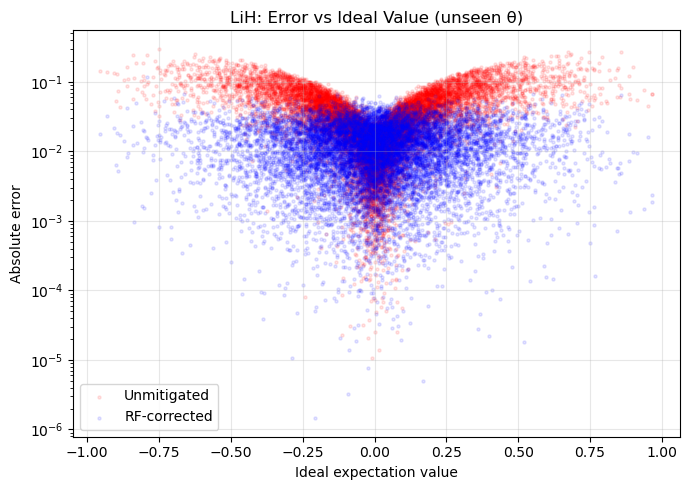

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
errors_unm = np.abs(y_test - X_test[:, 0])
errors_rf = np.abs(y_test - test_pred)

ax.scatter(y_test, errors_unm, alpha=0.1, s=5, color='red', label='Unmitigated')
ax.scatter(y_test, errors_rf, alpha=0.1, s=5, color='blue', label='RF-corrected')
ax.set_yscale('log')
ax.set_xlabel('Ideal expectation value')
ax.set_ylabel('Absolute error')
ax.set_title('LiH: Error vs Ideal Value (unseen θ)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('lih_rf_error.png', dpi=150, bbox_inches='tight')
plt.show()